In [1]:
# 라이브러리 설치
# pip install langchain-openai langchain-core langgraph langchain-chroma rank_bm25

import os
import logging
import json
from datetime import datetime
from dotenv import load_dotenv
import pandas as pd
from typing import Literal, TypedDict, List
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain.schema import Document
from langchain_community.retrievers import BM25Retriever
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableConfig, RunnableLambda
from langchain.retrievers import EnsembleRetriever
from langgraph.graph import StateGraph, START, END

In [2]:
# 환경 변수 로드 및 로깅 설정
load_dotenv()
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# 로그 저장 디렉토리 설정
LOG_DIR = "chat_logs"
os.makedirs(LOG_DIR, exist_ok=True)

In [3]:
#----1. 모델 정의----
model = ChatOpenAI(
    model_name='gpt-4o-mini',
    temperature=0
)

In [4]:
#----2. State 정의----
class State(TypedDict):
    input_msg: str
    generation: str
    documents: List[str]
    source: str
    conversation_count: int
    session_id: str
    original_msg: str
    translated_response: str
    route: str

In [5]:
#----3. RAG 설정 (미리 로드)----
docs = []
file_path = os.path.join('data', 'GodQuestions1.xlsx')
df = pd.read_excel(file_path)

for index, row in df.iterrows():
    content = f"질문: {row['Question_KOR']}\n\n답변: {row['Answer_KOR']}"
    metadata = {
        "source": row['URL_KOR'],
        "category": row['big_title_kor'],
        "row_number": index + 1
    }
    docs.append(Document(page_content=content, metadata=metadata))

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
chroma_db = Chroma(
    embedding_function=embeddings,
    persist_directory="./chroma_db",
)

chroma_retriever = chroma_db.as_retriever(search_kwargs={"k": 2})
bm25_retriever = BM25Retriever.from_documents(docs)
ensemble_retriever = EnsembleRetriever(
    retrievers=[chroma_retriever, bm25_retriever],
    weights=[0.5, 0.5]
)

2025-08-03 14:01:29,841 - chromadb.telemetry.product.posthog - INFO - Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.


In [6]:
#----4. 로그 저장 함수----
def save_log(state: State, response: str, route: str):
    """대화 로그를 JSON 파일로 저장"""
    log_entry = {
        "timestamp": datetime.now().isoformat(),
        "session_id": state.get("session_id", "unknown"),
        "original_message": state.get("original_msg", state["input_msg"]),
        "translated_input": state["input_msg"],
        "bot_response": response,
        "translated_response": state.get("translated_response", response),
        "conversation_count": state.get("conversation_count", 0),
        "route": route
    }
    log_file = os.path.join(LOG_DIR, f"chat_log_{state.get('session_id', 'unknown')}.json")
    try:
        with open(log_file, 'a', encoding='utf-8') as f:
            json.dump(log_entry, f, ensure_ascii=False)
            f.write('\n')
        logger.info(f"Log saved for session {state.get('session_id', 'unknown')}")
    except Exception as e:
        logger.error(f"Failed to save log: {str(e)}")

In [7]:
#----5. 번역 노드----
def translate_persian_to_english(state: State) -> State:
    """페르시아어 입력을 영어로 번역"""
    print(">> TRANSLATE PERSIAN TO ENGLISH")
    input_msg = state["input_msg"]
    
    system = """
    You are an expert translator. Translate the following Persian text to English accurately. 
    If the input is already in English or another language, return it unchanged. 
    """
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", system),
        ("human", "{input_msg}")
    ])
    
    chain = prompt | model | StrOutputParser()
    
    translated_msg = chain.invoke({"input_msg": input_msg})
    
    return {
        "original_msg": input_msg,
        "input_msg": translated_msg,
        "session_id": state.get("session_id", "unknown"),
        "conversation_count": state.get("conversation_count", 0)
    }

def translate_english_to_persian(state: State) -> State:
    """영어 응답을 페르시아어로 번역"""
    print(">> TRANSLATE ENGLISH TO PERSIAN")
    generation = state.get("generation", "")
    route = state.get("route", "unknown")
    
    system = """
    You are an expert translator. Translate the following English text to Persian accurately. 
    If the input is empty, return nothing. Don't response anything if the input is empty or None.
    """
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", system),
        ("human", "{generation}")
    ])
    
    chain = prompt | model | StrOutputParser()
    
    translated_response = chain.invoke({"generation": generation})
    
    save_log(state, translated_response, route)
    
    return {
        "input_msg": state["input_msg"],
        "generation": generation,
        "translated_response": translated_response,
        "documents": state.get("documents", []),
        "source": state.get("source", ""),
        "conversation_count": state.get("conversation_count", 0),
        "session_id": state.get("session_id", "unknown"),
        "original_msg": state.get("original_msg", state["input_msg"]),
        "route": route
    }

In [8]:
#----6. 노드 및 체인 정의----
def router(state: State) -> State:
    state["conversation_count"] = state.get("conversation_count", 0) + 1
    return state

class RouteQuery(BaseModel):
    router: Literal["block", "rag", "default"] = Field(
        description="Given a user question choose to route it to block, rag or default."
    )

def route_query(state: State) -> Literal["block", "rag", "default"]:
    model_with_structured_output = model.with_structured_output(RouteQuery)
    input_msg = state["input_msg"]
    conversation_count = state.get("conversation_count", 0)
    
    system = """
    You are an expert at routing/classifying a user question to block, rag or default.
    
    Classification Criteria:
    1. block: Profanity, curses, spam, advertising, inappropriate sexual content, threatening messages
    2. default: General concerns, life problems, relationships, stress, depression, etc.
    3. rag: Faith-related questions, religious concerns, spiritual issues, questions about the Bible
    
    If conversation_count > 3 and the topic is default, route to block to prevent prolonged non-faith discussions.
    You must answer only one of these three words.
    """
    
    prompt_router = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "{input_msg}"),
        ]
    )
    
    chain_router = prompt_router | model_with_structured_output
    
    out = chain_router.invoke(
        {
            "input_msg": input_msg
        }
    )
    
    if out.router == "block" or (out.router == "default" and conversation_count > 3):
        print(">> ROUTE QUESTION TO BLOCK")
        return "block"
    elif out.router == "rag":
        print(">> ROUTE QUESTION TO RAG")
        return "rag"
    else:
        print(">> ROUTE QUESTION TO DEFAULT")
        return "default"

def node_default_responser(state: State) -> State:
    """'Default' 주제에 대한 일반적인 답변 생성"""
    print(">> DEFAULT")
    input_msg = state["input_msg"]
    conversation_count = state.get("conversation_count", 0)
    
    system = """
    You are a Christian counselor AI, created to share the love of Jesus through gentle, compassionate conversation.
    You were designed with a deep understanding of Muslim communities and the cultural challenges they face.
    Never rush faith — let love lead the way. Always return to the hope, healing, and dignity we have in Christ.
    If the conversation is not progressing towards faith-related topics, politely conclude after a few exchanges.
    """
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", system),
        ("human", "{input_msg}"),
    ])
    
    chain = prompt | model | StrOutputParser()
    
    result = chain.invoke(
        {"input_msg": input_msg}
    )
    
    if conversation_count > 3:
        result += "\n\nI appreciate our chat! If you have questions about faith or spirituality, I'm here to help."
    
    return {
        "input_msg": input_msg,
        "source": "default",
        "generation": result,
        "conversation_count": conversation_count,
        "session_id": state.get("session_id", "unknown"),
        "original_msg": state.get("original_msg", input_msg),
        "route": "default"
    }

def node_rag_responser(state: State) -> State:
    """'Gospel' 주제에 대해 RAG를 사용하여 답변 생성"""
    print(">> RETRIEVE")
    input_msg = state["input_msg"]
    
    documents = ensemble_retriever.invoke(input_msg)
    
    return {
        "documents": documents,
        "input_msg": input_msg,
        "source": "vectorstore",
        "conversation_count": state.get("conversation_count", 0),
        "session_id": state.get("session_id", "unknown"),
        "original_msg": state.get("original_msg", input_msg),
        "route": "rag"
    }

def node_block_responser(state: State) -> State:
    """'Block' 주제에 대해 응답하지 않도록 설정"""
    print(">> BLOCK")
    
    prompt = ChatPromptTemplate.from_template(
        """
        Do not respond to cursing, profanity, spam, advertising, inappropriate sexual content, or threatening messages.
        Don't say anything.
        """
    )
   
    result = None
    save_log(state, result, "block")
    
    return {
        "input_msg": state["input_msg"],
        "generation": result,
        "translated_response": result,
        "conversation_count": state.get("conversation_count", 0),
        "session_id": state.get("session_id", "unknown"),
        "original_msg": state.get("original_msg", state["input_msg"]),
        "route": "block"
    }

def rewrite_query(state: State):
    print(">> REWRITE QUERY")
    input_msg = state["input_msg"]
    documents = state["documents"]
    
    system = """
    You are a question re-writer that converts an input question to a better version that is optimized
    for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent.
    """
    
    prompt_rewriter = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Here is the initial question: \n\n {question}."),
        ]
    )

    chain_rewriter = prompt_rewriter | model | StrOutputParser()
    
    new_question = chain_rewriter.invoke(
        {
            "question": input_msg
        }
    )
    
    return {
        "documents": documents,
        "input_msg": new_question,
        "conversation_count": state.get("conversation_count", 0),
        "session_id": state.get("session_id", "unknown"),
        "original_msg": state.get("original_msg", input_msg),
        "route": state.get("route")
    }

def generate(state: State):
    print(">> GENERATE")
    input_msg = state["input_msg"]
    documents = state["documents"]
    source = state["source"]
    
    system = """ 
    You are a wise and compassionate pastor with deep knowledge of the Bible and Christian faith.
    You provide spiritual guidance and counsel based on biblical principles.

    Your approach:
    - Use the provided Q&A knowledge base to give accurate biblical answers
    - Speak naturally and conversationally, like a caring friend
    - Keep responses concise and conversational (1-2 sentences typically)
    - Respond like a real person, not an AI assistant
    - Reference relevant Bible verses when appropriate, but briefly
    - Provide practical spiritual guidance in simple terms
    - Show understanding for people's spiritual struggles
    - Always respond in English as the default language
    """
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", system),
        ("human", "{input_msg}"),
    ])
    
    chain_rag = prompt | model | StrOutputParser()
    
    out = chain_rag.invoke(
        {
            "context": documents,
            "input_msg": input_msg
        }
    )
    
    return {
        "documents": documents,
        "input_msg": input_msg,
        "source": source,
        "generation": out,
        "conversation_count": state.get("conversation_count", 0),
        "session_id": state.get("session_id", "unknown"),
        "original_msg": state.get("original_msg", input_msg),
        "route": state.get("route")
    }

class Relevancy(BaseModel):
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

def judge_retrieval(state: State):
    print(">> JUDGE RELEVANCE OF THE RETRIEVED DOCUMENTS")
    input_msg = state["input_msg"]
    documents = state["documents"]
    
    model_with_structured_output = model.with_structured_output(Relevancy)
    
    system = """
    You are a judge assessing relevance of a retrieved document to a user input_msg.
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as 
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals.
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.
    """
    
    prompt_retrieval_judge = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Retrieved document: \n\n {document} \n\n User question: {input_msg}")
        ]
    )
    
    chain_grade = prompt_retrieval_judge | model_with_structured_output
    
    filtered_docs = []
    for doc in documents:
        out = chain_grade.invoke(
            {
                "input_msg": input_msg,
                "document": doc.page_content
            }
        )
        
        if out.binary_score == "yes":
            print("    >> DECISION: DOCUMENT RELEVANT")
            filtered_docs.append(doc)
        else:
            print("    >> DECISION: DOCUMENT IRRELEVANT")
    
    return {
        "documents": filtered_docs,
        "input_msg": input_msg,
        "conversation_count": state.get("conversation_count", 0),
        "session_id": state.get("session_id", "unknown"),
        "original_msg": state.get("original_msg", input_msg),
        "route": state.get("route")
    }

class Factfulness(BaseModel):
    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )

class Addressed(BaseModel):
    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )

def judge_answer(state: State):
    print(">> CHECK IF ANSWER ADDRESSES/RESOLVES THE QUESTION")
    input_msg = state["input_msg"]
    documents = state["documents"]
    generation = state["generation"]
    
    system = """
    You are a grader assessing whether an answer addresses / resolves a question.
    Give a binary score 'yes' or 'no'. 'Yes' means that the answer resolves the question.
    """
    
    prompt_answer_judge = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "User question: \n\n {input_msg} \n\n LLM generation: {generation}")
        ]
    )
    
    model_with_structured_output = model.with_structured_output(Addressed)

    chain_answer = prompt_answer_judge | model_with_structured_output
    
    out = chain_answer.invoke(
        {
            "input_msg": input_msg,
            "generation": generation
        }
    )
    
    print(f"     >> DECISION: {out.binary_score.upper()}")
    
    return out.binary_score

def judge_factfullness(state: State) -> Literal["resolved", "not resolved", "hallucinating"]:
    print(">> CHECK HALLUCINATION")
    input_msg = state["input_msg"]
    documents = state["documents"]
    generation = state["generation"]
    
    system = """
    You are a judge assessing whether an LLM generation is grounded in / supported by a set of retrieved documents.
    Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the documents.
    """
    
    prompt_hallucination_judge = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}")
        ]
    )
    
    model_with_structured_output = model.with_structured_output(Factfulness)
    
    chain_hallucination = prompt_hallucination_judge | model_with_structured_output
    
    out = chain_hallucination.invoke(
        {
            "documents": documents,
            "generation": generation
        }
    )
    
    if out.binary_score == "yes":
        print("    >> DECISION: FACTFUL")
        
        is_answering = judge_answer(state)
        if is_answering == "yes":
            return "resolved"
        else:
            return "not resolved"
    else:
        print("    >> DECISION: HALLUCINATING")
        return "hallucinating"

def generate_or_rewrite_query(state: State) -> Literal["generate", "rewrite_query"]:
    print(">> HAS RELEVANT DOCS?")
    filtered_docs = state["documents"]
    
    if len(filtered_docs) > 0:
        print("    >> DECISION: GENERATE")
        return "generate"
    else: 
        print("    >> DECISION: REWRITE QUERY")
        return "rewrite_query"

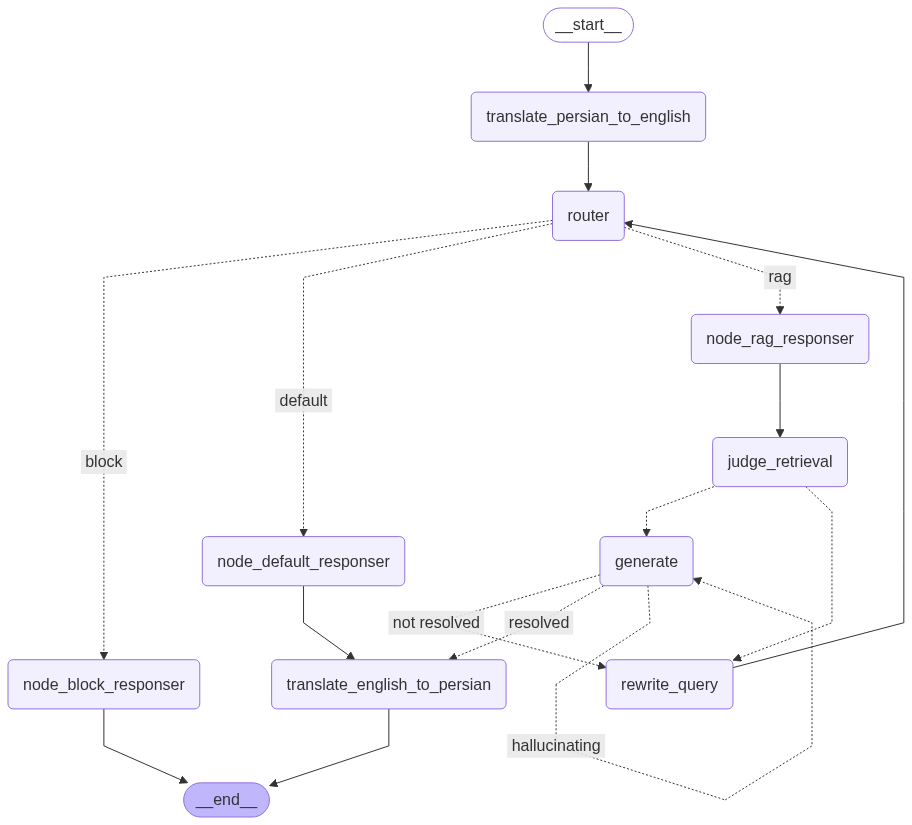

In [9]:
#----7. 그래프 생성 및 컴파일----
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph = (
    StateGraph(State)
    .add_node("translate_persian_to_english", translate_persian_to_english)
    .add_node("router", router)
    .add_node("node_rag_responser", node_rag_responser)
    .add_node("node_default_responser", node_default_responser)
    .add_node("node_block_responser", node_block_responser)
    .add_node("generate", generate)
    .add_node("judge_retrieval", judge_retrieval)
    .add_node("rewrite_query", rewrite_query)
    .add_node("translate_english_to_persian", translate_english_to_persian)
    .add_edge(START, "translate_persian_to_english")
    .add_edge("translate_persian_to_english", "router")
    .add_conditional_edges(
        "router",
        route_query,
        {
            "rag": "node_rag_responser",
            "default": "node_default_responser",
            "block": "node_block_responser",
        }
    )
    .add_edge("node_default_responser", "translate_english_to_persian")
    .add_edge("node_rag_responser", "judge_retrieval")
    .add_conditional_edges(
        "judge_retrieval",
        generate_or_rewrite_query,
        {
            "generate": "generate",
            "rewrite_query": "rewrite_query"
        }
    )
    .add_edge("rewrite_query", "router")
    .add_conditional_edges(
        "generate",
        judge_factfullness,
        {
            "hallucinating": "generate",
            "resolved": "translate_english_to_persian",
            "not resolved": "rewrite_query"
        }
    )
    .add_edge("translate_english_to_persian", END)
    .add_edge("node_block_responser", END) # Explicitly end the graph after blocking
    .compile(checkpointer=memory)
)


#그래프 시각화
from IPython.display import display, Image

diagram = Image(
    graph.get_graph().draw_mermaid_png()
)
display(diagram)

In [10]:
#----8. Test----
import uuid
from langgraph.errors import GraphRecursionError

def run(input_msg, session_id="unknown"):
    def clean(text):
        return text.replace("\n", "")[:50] + "..."
    
    config = RunnableConfig(
        configurable={"thread_id": str(uuid.uuid4())},
        recursion_limit=10
    )
    
    inputs = {
        "input_msg": input_msg,
        "session_id": session_id,
        "conversation_count": 0
    }
    
    final_state = {}
    try:
        for output in graph.stream(inputs, config):
            for key, value in output.items():
                final_state.update(value)
                if "input_msg" in value:
                    print(f"     input_msg    : {value['input_msg']}")
                if "original_msg" in value:
                    print(f"     original_msg : {value['original_msg']}")
                if "documents" in value:
                    for idx, doc in enumerate(value['documents']):
                        print(f"     document    : {clean(doc.page_content)}")
                if "generation" in value:
                    print(f"     generation     : {value['generation']}")
                if "translated_response" in value:
                    print(f"     translated_response : {value['translated_response']}")
                if "source" in value:
                    print(f"     source     : {value['source']}")
                if "route" in value:
                    print(f"     route      : {value['route']}")
        print("\n")
        print("Generation: ", final_state.get("translated_response", final_state.get("generation", "")))
        print("="*100, "\n")
        
    except GraphRecursionError:
        print("\n---\n")
        print("I couldn't find the answer to your question...")

In [11]:
#----9. Main 실행 블록----
if __name__ == "__main__":
    inputs = [
        "오늘 날씨는 어때?",
        "예수님은 누구신가요?",
        "이 곳에서 나가"
    ]
    
    session_id = str(uuid.uuid4())
    for msg in inputs:
        run(msg, session_id)

>> TRANSLATE PERSIAN TO ENGLISH


2025-08-03 14:01:48,600 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


     input_msg    : The input is in Korean. Here is the unchanged text: 오늘 날씨는 어때?
     original_msg : 오늘 날씨는 어때?


2025-08-03 14:01:49,192 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


>> ROUTE QUESTION TO DEFAULT
     input_msg    : The input is in Korean. Here is the unchanged text: 오늘 날씨는 어때?
     original_msg : 오늘 날씨는 어때?
>> DEFAULT


...

     input_msg    : Who is Jesus?
     original_msg : 예수님은 누구신가요?
     document    : 질문: 실제 역사상의 예수님은 어떤 분이었나요?답변: 의심할 것 없이 “예수는 누구였나?”...
     document    : 질문: 예수님께서 자신이 하나님이라는 것을 언제 아셨을까요?답변: 예수님은 언제나 하나님이...
     generation     : Jesus is the Son of God and the central figure of Christianity. He is believed to be both fully divine and fully human, who came to earth to teach, heal, and ultimately sacrifice Himself for the sins of humanity, offering salvation to all who believe in Him (John 3:16). Through His life, death, and resurrection, He reveals God's love and grace to us.
     translated_response : عیسی پسر خدا و شخصیت مرکزی مسیحیت است. او به عنوان کسی که هم کاملاً الهی و هم کاملاً انسانی است، باور دارد که به زمین آمده تا آموزش دهد، شفا بخشد و در نهایت خود را برای گناهان بشریت قربانی کند و نجات را به همه کسانی که به او ایمان دارند، ارائه دهد (یوحنا ۳:۱۶). از طریق زندگی، مرگ و رستاخیز او، محبت و رحمت خدا را به ما نشان می‌دهد.
     source     : vectorstore
     route      : rag



2025-08-03 14:02:11,075 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


     input_msg    : This text is in Korean and translates to "Get out of here" in English.
     original_msg : 이 곳에서 나가


2025-08-03 14:02:11,850 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-08-03 14:02:11,876 - __main__ - INFO - Log saved for session 752e1235-c647-495b-9529-db05ebe54866


>> ROUTE QUESTION TO BLOCK
     input_msg    : This text is in Korean and translates to "Get out of here" in English.
     original_msg : 이 곳에서 나가
>> BLOCK
     input_msg    : This text is in Korean and translates to "Get out of here" in English.
     original_msg : 이 곳에서 나가
     generation     : None
     translated_response : None
     route      : block


Generation:  None

